In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
import os
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [5]:
latent_dim = 100
batch_size = 256
# First run with 20 epochs
EPOCHS = 20
num_examples_to_generate = 16
print("Latent Dimension:", latent_dim)
print("Batch Size:", batch_size)
print("Epochs:", EPOCHS)

Latent Dimension: 100
Batch Size: 256
Epochs: 20


In [7]:
(x_train, _), (_, _) = mnist.load_data()

In [9]:
x_train = x_train.reshape(
    x_train.shape[0],
    28,
    28,
    1
).astype("float32")

# Normalize from [0, 255] to [-1, 1]
x_train = (x_train - 127.5) / 127.5

print("Normalized training data shape:", x_train.shape)
print("Minimum value:", x_train.min())
print("Maximum value:", x_train.max())


Normalized training data shape: (60000, 28, 28, 1)
Minimum value: -1.0
Maximum value: 1.0


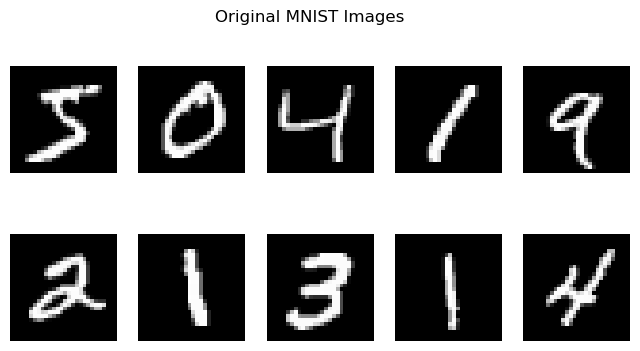

In [11]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    # Convert [-1, 1] back to [0, 1]
    image = (x_train[i, :, :, 0] * 0.5) + 0.5

    plt.imshow(image, cmap="gray")
    plt.axis("off")

plt.suptitle("Original MNIST Images")
plt.show()


In [13]:
def build_generator():

    model = keras.Sequential(name="generator")

    # Input random noise vector
    model.add(
        layers.Input(shape=(latent_dim,))
    )

    # Dense layer
    model.add(
        layers.Dense(
            7 * 7 * 256,
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Reshape
    model.add(
        layers.Reshape((7, 7, 256))
    )

    # 7 x 7 x 256 -> 7 x 7 x 128
    model.add(
        layers.Conv2DTranspose(
            128,
            (5, 5),
            strides=(1, 1),
            padding="same",
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # 7 x 7 x 128 -> 14 x 14 x 64
    model.add(
        layers.Conv2DTranspose(
            64,
            (5, 5),
            strides=(2, 2),
            padding="same",
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # 14 x 14 x 64 -> 28 x 28 x 1
    model.add(
        layers.Conv2DTranspose(
            1,
            (5, 5),
            strides=(2, 2),
            padding="same",
            use_bias=False,
            activation="tanh"
        )
    )

    return model


generator = build_generator()

print("--- Generator Model Summary ---")
generator.summary()


--- Generator Model Summary ---


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

In [15]:
noise = tf.random.normal([1, latent_dim])
# Generate an image
generated_image = generator(
    noise,
    training=False
)
print("Generated image shape:", generated_image.shape)

Generated image shape: (1, 28, 28, 1)


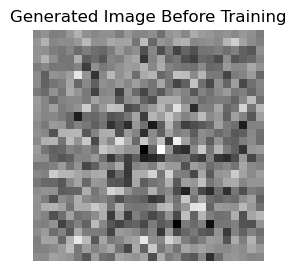

In [17]:
plt.figure(figsize=(3, 3))

plt.imshow(
    generated_image[0, :, :, 0],
    cmap="gray"
)

plt.axis("off")
plt.title("Generated Image Before Training")
plt.show()

In [19]:
def build_discriminator():

    model = keras.Sequential(name="discriminator")

    # Input layer
    model.add(
        layers.Input(shape=(28, 28, 1))
    )

    # First convolution
    model.add(
        layers.Conv2D(
            64,
            (5, 5),
            strides=(2, 2),
            padding="same"
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Second convolution
    model.add(
        layers.Conv2D(
            128,
            (5, 5),
            strides=(2, 2),
            padding="same"
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Flatten
    model.add(layers.Flatten())

    # Output
    model.add(
        layers.Dense(
            1,
            activation="sigmoid"
        )
    )

    return model


discriminator = build_discriminator()

print("--- Discriminator Model Summary ---")
discriminator.summary()


--- Discriminator Model Summary ---


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
decision = discriminator(
    generated_image,
    training=False
)

print("Discriminator output:", decision.numpy())


Discriminator output: [[0.50073105]]


In [23]:
decision = discriminator(
    generated_image,
    training=False
)

print("Discriminator output:", decision.numpy())


Discriminator output: [[0.50073105]]


In [25]:
cross_entropy = keras.losses.BinaryCrossentropy(
    from_logits=False
)


def discriminator_loss(real_output, fake_output):

    # Real images should be classified as 1
    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    # Fake images should be classified as 0
    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    return real_loss + fake_loss


def generator_loss(fake_output):

    # Generator wants fake images classified as real
    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

print("Loss functions created successfully.")


Loss functions created successfully.


In [27]:
generator_optimizer = keras.optimizers.Adam(
    learning_rate=1e-4
)

discriminator_optimizer = keras.optimizers.Adam(
    learning_rate=1e-4
)

print("Optimizers created successfully.")


Optimizers created successfully.


In [29]:
train_dataset = (
    tf.data.Dataset
    .from_tensor_slices(x_train)
    .shuffle(x_train.shape[0])
    .batch(batch_size)
)

print("Training dataset created successfully.")

for image_batch in train_dataset.take(1):
    print("Batch shape:", image_batch.shape)

Training dataset created successfully.
Batch shape: (256, 28, 28, 1)


In [31]:
seed = tf.random.normal(
    [
        num_examples_to_generate,
        latent_dim
    ]
)

print("Seed shape:", seed.shape)

Seed shape: (16, 100)


In [33]:
@tf.function
def train_step(images):

    # Generate random noise
    noise = tf.random.normal(
        [
            batch_size,
            latent_dim
        ]
    )

    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        # Generate fake images
        generated_images = generator(
            noise,
            training=True
        )

        # Discriminator output for real images
        real_output = discriminator(
            images,
            training=True
        )

        # Discriminator output for fake images
        fake_output = discriminator(
            generated_images,
            training=True
        )

        # Calculate losses
        gen_loss = generator_loss(
            fake_output
        )

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    # Generator gradients
    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    # Discriminator gradients
    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    # Update Generator
    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    # Update Discriminator
    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

In [35]:
def generate_and_save_images(
    model,
    epoch,
    test_input
):

    # Generate images
    predictions = model(
        test_input,
        training=False
    )

    # Convert [-1, 1] to [0, 1]
    predictions_rescaled = (
        predictions * 0.5
    ) + 0.5

    # Create figure
    fig = plt.figure(figsize=(6, 6))

    # Display 16 images
    for i in range(
        predictions.shape[0]
    ):

        plt.subplot(
            4,
            4,
            i + 1
        )

        plt.imshow(
            predictions_rescaled[
                i, :, :, 0
            ],
            cmap="gray"
        )

        plt.axis("off")

    plt.suptitle(
        f"Generated Images - Epoch {epoch}",
        fontsize=14
    )

    # Create folder
    if not os.path.exists("images"):
        os.makedirs("images")

    # Save image
    filename = (
        f"images/image_at_epoch_{epoch:04d}.png"
    )

    plt.savefig(
        filename,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print("Saved:", filename)

In [39]:
def train(dataset, epochs):

    print("\n======================================")
    print("       BEGINNING GAN TRAINING")
    print("======================================")

    for epoch in range(epochs):

        gen_loss_list = []
        disc_loss_list = []

        # Process all batches
        for image_batch in dataset:

            gen_loss, disc_loss = train_step(
                image_batch
            )

            gen_loss_list.append(
                gen_loss.numpy()
            )

            disc_loss_list.append(
                disc_loss.numpy()
            )

        # Average losses
        avg_gen_loss = np.mean(
            gen_loss_list
        )

        avg_disc_loss = np.mean(
            disc_loss_list
        )

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Generator Loss: {avg_gen_loss:.4f} | "
            f"Discriminator Loss: {avg_disc_loss:.4f}"
        )

        # Generate images every 20 epochs
        if (
            (epoch + 1) % 20 == 0
            or
            (epoch + 1) == 1
        ):

            generate_and_save_images(
                generator,
                epoch + 1,
                seed
            )

    print("TRAINING COMPLETE")
    # Final generated images
    generate_and_save_images(
        generator,
        epochs,
        seed
    )

Starting GAN training...

       BEGINNING GAN TRAINING
Epoch 1/20 | Generator Loss: 0.7737 | Discriminator Loss: 1.0503


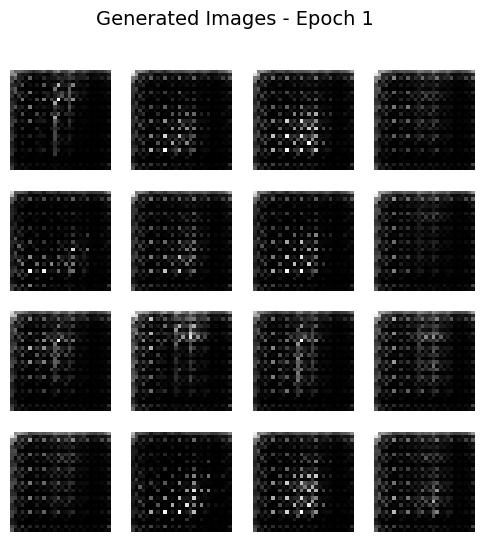

Saved: images/image_at_epoch_0001.png
Epoch 2/20 | Generator Loss: 0.9583 | Discriminator Loss: 1.1461
Epoch 3/20 | Generator Loss: 0.9221 | Discriminator Loss: 1.1424
Epoch 4/20 | Generator Loss: 0.9280 | Discriminator Loss: 1.2238
Epoch 5/20 | Generator Loss: 0.7899 | Discriminator Loss: 1.3344
Epoch 6/20 | Generator Loss: 0.8203 | Discriminator Loss: 1.3002
Epoch 7/20 | Generator Loss: 0.8462 | Discriminator Loss: 1.2889
Epoch 8/20 | Generator Loss: 0.8703 | Discriminator Loss: 1.2516
Epoch 9/20 | Generator Loss: 0.8917 | Discriminator Loss: 1.2289
Epoch 10/20 | Generator Loss: 0.9063 | Discriminator Loss: 1.2760
Epoch 11/20 | Generator Loss: 1.0516 | Discriminator Loss: 1.0634
Epoch 12/20 | Generator Loss: 0.9834 | Discriminator Loss: 1.2159
Epoch 13/20 | Generator Loss: 1.1377 | Discriminator Loss: 1.0719
Epoch 14/20 | Generator Loss: 1.1228 | Discriminator Loss: 1.0921
Epoch 15/20 | Generator Loss: 1.1906 | Discriminator Loss: 1.0587
Epoch 16/20 | Generator Loss: 1.1102 | Discrim

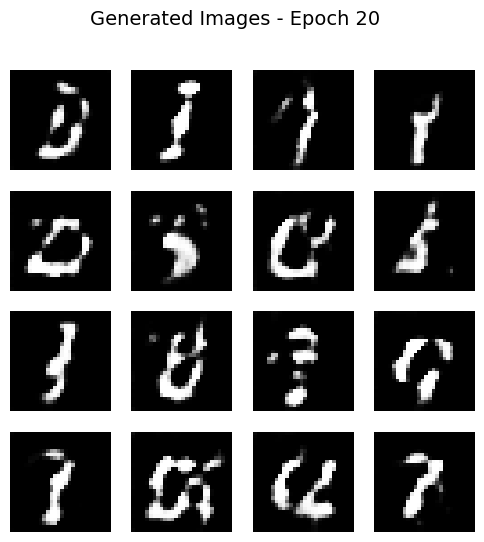

Saved: images/image_at_epoch_0020.png
TRAINING COMPLETE


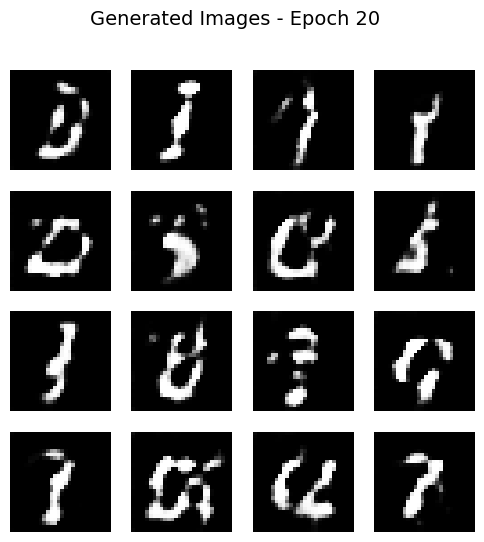

Saved: images/image_at_epoch_0020.png


In [41]:
print("Starting GAN training...")

train(
    train_dataset,
    EPOCHS
)

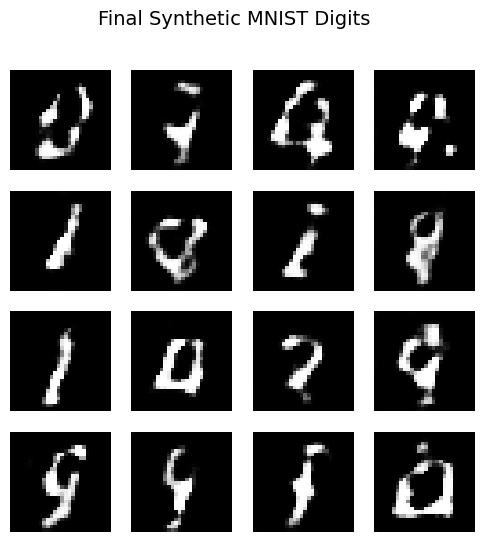

In [44]:
new_noise = tf.random.normal(
    [16, latent_dim]
)

# Generate images
new_images = generator(
    new_noise,
    training=False
)

# Convert [-1,1] to [0,1]
new_images = (
    new_images * 0.5
) + 0.5

# Display images
plt.figure(figsize=(6, 6))

for i in range(16):

    plt.subplot(
        4,
        4,
        i + 1
    )

    plt.imshow(
        new_images[i, :, :, 0],
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Final Synthetic MNIST Digits",
    fontsize=14
)

plt.show()